# Statistics 336 Final Project 
## Gabe Rice 

In this notebook, I will document the process of replicating and querying data in Python. The Majority of this work will involve translating the first exam in this class into a Python format. This will be done using a variety of libraries, including Pandas, Numpy, and other online database sources, which will be explained in more depth as they are encountered in the notebook. Sections of this notebook will be dedicated to translating the given Python Query into other languages.

The first part of this exam will be dedicated to Lahman stuff. When answering these questions I will be using the exported data sets from Rstudio that I have written to CSV files and saved on my machine locally

### Q1: How many times since 1970 has a team lost 100 or more games in a season?

In [ ]:
import pandas as pd

Teams = pd.read_csv('data/Teams.csv')

hundred_loss_teams = Teams.query('yearID >= 1970 and L >= 100')

len(hundred_loss_teams)

73

#### Q1 Equivlent R Code:
```
q1 <- Teams |> 
  filter(yearID >= 1970, L >= 100)
```

###  Q2: Among all players who have stolen 200 or more bases in their career, who has the most career home runs?  Find the top ten.

In [ ]:
Batting = pd.read_csv('data/Batting.csv')
People = pd.read_csv('data/People.csv')


# Group by playerID and sum SB & HR
q2a = (
    Batting
    .groupby('playerID')
    .agg(sum_sb=('SB', 'sum'), sum_hr=('HR', 'sum'))
    .reset_index()
)

# Step 2: Left join with People
q2a = pd.merge(
    q2a,
    People[['playerID', 'nameFirst', 'nameLast']],
    on='playerID',
    how='left'
)

# Step 3: Filter (sum_sb >= 200), sort, and deduplicate
q2a = (
    q2a[q2a['sum_sb'] >= 200]      # Filter
    .sort_values('sum_hr', ascending=False)  # Arrange desc
    .drop_duplicates('playerID')    # Equivalent to distinct(.keep_all=TRUE)
    [['playerID', 'nameFirst', 'nameLast', 'sum_hr', 'sum_sb']]  # Select columns
)

# Display top 10
q2a.head(10)

,playerID,nameFirst,nameLast,sum_hr,sum_sb
1715,bondsba01,Barry,Bonds,762,514.0
1,aaronha01,Hank,Aaron,755,240.0
15867,rodrial01,Alex,Rodriguez,696,329.0
11859,mayswi01,Willie,Mays,660,338.0
17612,sosasa01,Sammy,Sosa,609,234.0
15819,robinfr02,Frank,Robinson,586,204.0
9010,jacksre01,Reggie,Jackson,563,228.0
17018,sheffga01,Gary,Sheffield,509,253.0
20245,winfida01,Dave,Winfield,465,223.0
2778,cansejo01,Jose,Canseco,462,200.0


#### Q2 Equivlent R Code:
```
q2a <- Batting |> 
  group_by(playerID) |>
  mutate(sum_sb = sum(SB, na.rm = TRUE)) |> 
  mutate(sum_hr = sum(HR, na.rm = TRUE)) |> 
  left_join(People, by="playerID") |> 
  filter(sum_sb >= 200) |> 
  arrange(desc(sum_hr)) |> 
  distinct(playerID, .keep_all = TRUE) |>
  select(playerID, nameFirst, nameLast, sum_hr, sum_sb)
```

### Q2b:  make a scatter plot with career HRs on x and career SB on y.  Put all players with more than 3000 career AB on your chart.   

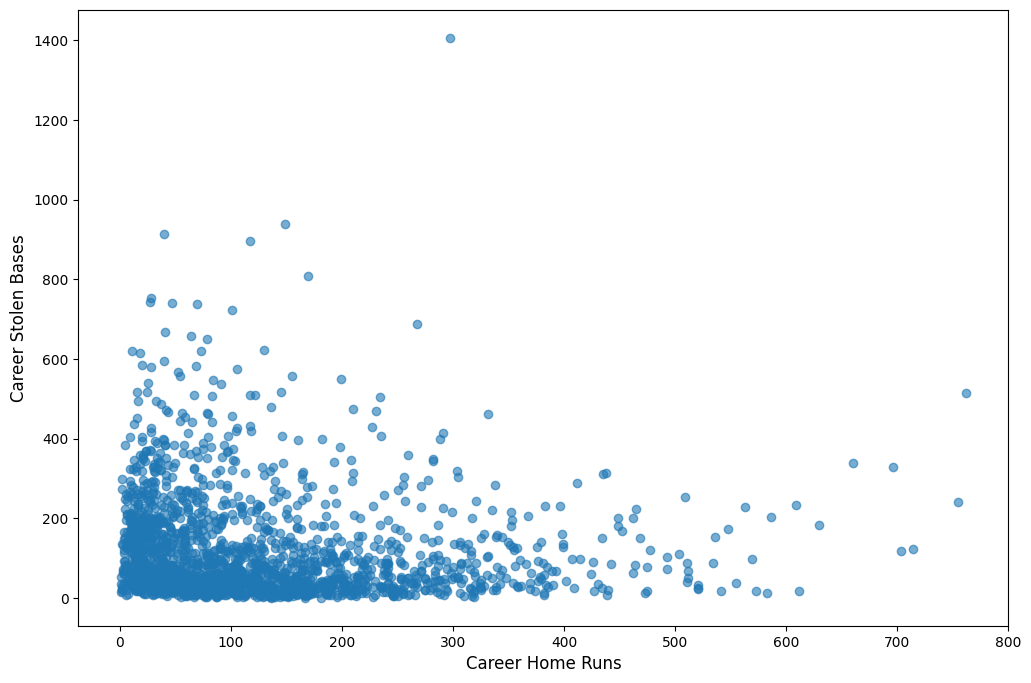

In [ ]:
import matplotlib.pyplot as plt

Batting = pd.read_csv('data/Batting.csv')
People = pd.read_csv('data/People.csv')


# Group by playerID and sum SB & HR
q2b = (
    Batting
    .groupby('playerID')
    .agg(sum_sb=('SB', 'sum'), sum_hr=('HR', 'sum'), sum_ab=('AB', 'sum'))
    .reset_index()
    .fillna(0)
)

# Step 2: Left join with People
q2b = pd.merge(
    q2b,
    People[['playerID', 'nameFirst', 'nameLast']],
    on='playerID',
    how='left'
)

# Create full name column
q2b['name'] = q2b['nameFirst'] + ' ' + q2b['nameLast']

# Filter for players with >3000 AB
qualified_players = q2b[q2b['sum_ab'] > 3000]

plt.figure(figsize=(12, 8))
plt.scatter(qualified_players['sum_hr'], 
            qualified_players['sum_sb'])

plt.xlabel('Career Home Runs')
plt.ylabel('Career Stolen Bases')

plt.show()

#### Q2b Equivlent R Code:
```
q2b <- Batting |> 
  group_by(playerID) |>
  mutate(sum_sb = sum(SB, na.rm = TRUE)) |> 
  mutate(sum_hr = sum(HR, na.rm = TRUE)) |> 
  mutate(sum_ab = sum(AB, na.rm = TRUE)) |> 
  filter(sum_sb >= 200, sum_ab > 3000) |> 
  left_join(People, by="playerID") |> 
  arrange(desc(sum_hr)) |> 
  distinct(playerID, .keep_all = TRUE) |>
  select(playerID, nameFirst, nameLast, sum_hr, sum_sb)

ggplot(data = q2b, aes(x = sum_hr, y = sum_sb)) + geom_point()
```

### Q3: How many players have won the Cy Young award in both the AL and the NL? Make a nice table with player names rather than just IDs.

In [37]:
awards = pd.read_csv('data/AwardsPlayers.csv')
people = pd.read_csv('data/People.csv')

# Get only Cy Young winners
cy_young = awards[awards['awardID'] == 'Cy Young Award']

# Group by playerID and count distinct leagues they won in
league_wins = cy_young.groupby('playerID')['lgID'].nunique()

# Find players who won in both leagues (count = 2)
winners_both = league_wins.reset_index().query('lgID == 2')['playerID']

# Merge with people data to get names
result = pd.merge(
    pd.Series(winners_both, name='playerID'),
    people[['playerID', 'nameFirst', 'nameLast']],
    on='playerID'
)


num_players = len(result)

print(f"Number of players who won Cy Young in both AL and NL: {num_players}")
print(result[['nameFirst', 'nameLast']])

Number of players who won Cy Young in both AL and NL: 7
  nameFirst  nameLast
0     Roger   Clemens
1       Roy  Halladay
2     Randy   Johnson
3     Pedro  Martinez
4   Gaylord     Perry
5       Max  Scherzer
6     Blake     Snell


#### Q3 Equivlent R Code:
```
 AwardsPlayers %>%
  filter(awardID == "Cy Young Award") %>%
  group_by(playerID) %>%
  filter(n_distinct(lgID) == 2) %>%
  left_join(people %>% select(playerID, nameFirst, nameLast), by = "playerID") %>%
  distinct(nameFirst, nameLast)
```

## Questions 4-6
These questions are going to be using NFL data. I could not find an exact equivalent to the NFLFASTR Python library, thankfully. In the exam, only the year 2003 was relevant for the provided questions. Similar to questions 1-3, I will be using a CSV file extracted from the RStudio data. 

### Q4: In the 2003 regular season, how many times did a team convert 3rd and 15 or more?

In [ ]:
pbp2003 = pd.read_csv('data/PBP2003.csv')

q4 = (pbp2003[(pbp2003['down'] == 3) & 
              (pbp2003['ydstogo'] >= 15) & 
              (pbp2003['play_type'].isin(['pass', 'run']))] # isin filters rows where a column's value is contained in a specified list of values 
      .groupby('posteam') # group by posteam
      .size() # then counts all rows, n() in RStudio
      .reset_index(name='conversions') # finnaly renames the count column
      .sort_values('conversions', ascending=False)) # sort values based on that column

q4.head(10)

/var/folders/wf/_rnchz9x14366p91s96x6x0h0000gn/T/ipykernel_82379/98329459.py:1: DtypeWarning: Columns (37,45,179,180,189,190,193,194,197,198,203,204,205,206,211,212,213,214,218,219,220,253,254,255,260,262,263,283,284) have mixed types. Specify dtype option on import or set low_memory=False.
  pbp2003 = pd.read_csv('data/PBP2003.csv')


,posteam,conversions
25,PHI,26
18,LV,25
29,TB,25
21,NE,25
4,CAR,24
23,NYG,24
22,NO,21
8,DAL,21
19,MIA,20
3,BUF,20


#### Q4 Equivlent R Code:
```
q4 <- pbp2003 |> 
  filter(down == 3, ydstogo >= 15, play_type == "pass" | play_type == "run") |> 
  count(posteam, name = "conversions")
```

### Q5:  Make a table that shows each team's longest 3rd-down conversion of the 2003 regular season. (for example, the longest 3rd down that Arizona successfully converted in 2003 was 20 yards.)

In [53]:
pbp2003 = pd.read_csv('data/PBP2003.csv')

q5 = (pbp2003[(pbp2003['down'] == 3) & 
              (pbp2003['play_type'].isin(['pass', 'run']))] # isin 
      .groupby('posteam')
      .agg(longest_conversion=('ydstogo', 'max'))
      .sort_values('longest_conversion', ascending=False))

q5.head()

/var/folders/wf/_rnchz9x14366p91s96x6x0h0000gn/T/ipykernel_82379/1805028635.py:1: DtypeWarning: Columns (37,45,179,180,189,190,193,194,197,198,203,204,205,206,211,212,213,214,218,219,220,253,254,255,260,262,263,283,284) have mixed types. Specify dtype option on import or set low_memory=False.
  pbp2003 = pd.read_csv('data/PBP2003.csv')


,longest_conversion
posteam,
CAR,35
DET,34
NE,33
BAL,33
NYG,32


#### Q5: Equivlent R Code:
```
q5 <- pbp2003 |> 
  filter(down == 3, play_type == "pass" | play_type == "run") |> 
  group_by(posteam) |> 
  summarise(longest_conversion = max(ydstogo, na.rm = TRUE))
```

### Q5b: Make a bar chart out of this data

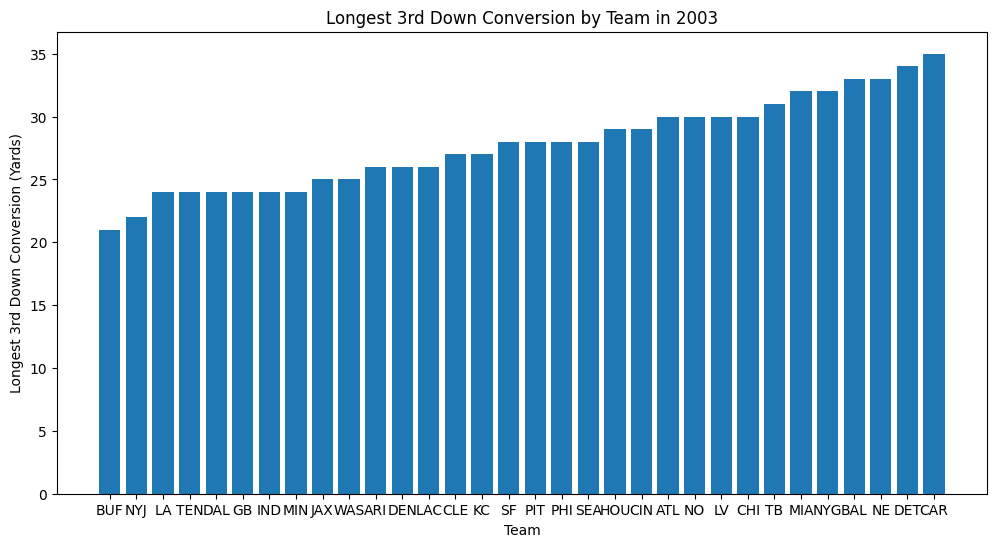

In [63]:
import matplotlib.pyplot as plt

q5_sorted = q5.sort_values('longest_conversion', ascending=True)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Create bar chart
plt.bar(q5_sorted.index, q5_sorted['longest_conversion'])


# Customize the chart
ax.set_title('Longest 3rd Down Conversion by Team in 2003')
ax.set_xlabel('Team')
ax.set_ylabel('Longest 3rd Down Conversion (Yards)')

plt.show()

#### Q5b: Equivlent R Code:
```
ggplot(q5, aes(x = fct_reorder( posteam, longest_conversion ), y = longest_conversion)) +
  geom_bar(stat = "identity") +
  labs(x = "Team", y = "Longest 3rd Down Conversion (Yards)", 
       title = "Longest 3rd Down Conversion by Team in 2003")
```

### Q6: During the 2003 regular season, find all instances where a team had three or more plays of 40+ yards in one week and then had zero plays of 40 or more yards in the next week.

In [ ]:
pbp2003 = pd.read_csv('data/PBP2003.csv')

q6 = (pbp2003[pbp2003['yards_gained'].notna() & (pbp2003['week'] <= 17)]
      .groupby(['posteam', 'week'])
      .agg(plays_40_plus=('yards_gained', lambda x: (x >= 40).sum()))
      .reset_index()
      .sort_values(['posteam', 'week'])
      .assign(next_week_plays_40_plus=lambda x: x.groupby('posteam')['plays_40_plus'].shift(-1)) # shift(1 or -1) == R's lead() or lag()
      .query('plays_40_plus >= 3 and next_week_plays_40_plus == 0')
      [['posteam', 'week', 'plays_40_plus', 'next_week_plays_40_plus']])

q6

# Had to learn lambda functions on the fly for this one, basicly a lambda function is just an inline function.
# In the case of using it for this query we are just creating a fucntion within the line of this query
# Assign add new columns to a DataFrame. assign = mutate. agg = select

/var/folders/wf/_rnchz9x14366p91s96x6x0h0000gn/T/ipykernel_82379/2894061781.py:1: DtypeWarning: Columns (37,45,179,180,189,190,193,194,197,198,203,204,205,206,211,212,213,214,218,219,220,253,254,255,260,262,263,283,284) have mixed types. Specify dtype option on import or set low_memory=False.
  pbp2003 = pd.read_csv('data/PBP2003.csv')


,posteam,week,plays_40_plus,next_week_plays_40_plus
33,BAL,2,3,0.0
42,BAL,12,3,0.0
128,DAL,1,3,0.0
146,DEN,3,4,0.0
329,MIN,11,3,0.0
332,MIN,14,3,0.0
461,SF,15,3,0.0


#### Q6: Equivlent R Code:
```
q6 <- pbp2003 |> 
  filter(!is.na(yards_gained), week <= 17) |> 
  group_by(posteam, week) |> 
  summarise(plays_40_plus = sum(yards_gained >= 40, na.rm = TRUE)) |> 
  mutate(next_week_plays_40_plus = lead(plays_40_plus)) |> 
  filter(plays_40_plus >= 3, next_week_plays_40_plus == 0) |> 
  select(posteam, week, plays_40_plus, next_week_plays_40_plus)
```

## Questions 7-9
For the weHoop packages, were going to be using a package called SportsDataVerse. The goal of sportsdataverse-py is to provide the community with a python package for working with sports data as a companion to the cfbfastR, hoopR, and wehoop R packages. If you look at some of the other test files I've worked on you'll see that I have some expirence using this library, and for your purposes could be worth investigating.

You can find a link to the website [here](https://www.sportsdataverse.org/)

#### Q7: are there any instances in the data where the team_id is the same but the team_location is different?  Hint: yes!  Make a table with team_id in one column, and a list of different team locations in another column.

In [ ]:
from sportsdataverse import wbb
import pandas as pd

wbb_data = pd.concat([wbb.load_wbb_team_boxscore(seasons=year, return_as_pandas=True) for year in [2021, 2022, 2023, 2024]])

q7 = (wbb_data
      .groupby('team_id')['team_location']
      .agg(lambda x: ', '.join(x.unique()))
      .reset_index(name='names')
      .loc[lambda x: x['names'].str.contains(',')])

q7.head()

100%|██████████| 1/1 [00:00<00:00,  2.89it/s]


,team_id,names
66,113,"UMass, Massachusetts"
139,244,"St. Edwards, St. Edward's"
184,316,"Dickinson State, Dickinson State (ND)"
202,380,"Anderson, Anderson (SC)"
205,399,"Albany, UAlbany"


#### Q7: Equivlent R Code:
```
q7 <- wcbb_data |> 
  group_by(team_id) |> 
  summarise(names = toString(unique(team_location))) |> 
  filter(grepl(",", names))
```

### Q8: make a table with every team and their winning percentage for the entire 4-season period. sort from highest to lowest.

In [92]:
from sportsdataverse import wbb
import pandas as pd

wbb_data = pd.concat([wbb.load_wbb_team_boxscore(seasons=year, return_as_pandas=True) for year in [2021, 2022, 2023, 2024]])

q8 = (wbb_data
      .groupby(['team_id', 'team_location'])
      .agg(win_pct=('team_winner', 'mean'))
      .reset_index()                          # Convert team_id back to column
      .query('win_pct > 0 & win_pct < 1')
      .sort_values('win_pct', ascending=False)
      )

q8.head(10)

100%|██████████| 1/1 [00:00<00:00,  2.44it/s]


,team_id,team_location,win_pct
547,2579,South Carolina,0.944056
232,526,Florida Gulf Coast,0.887218
14,24,Stanford,0.871429
23,41,UConn,0.859155
381,2250,Gonzaga,0.846154
479,2439,UNLV,0.822581
97,163,Princeton,0.822222
542,2571,South Dakota State,0.80916
88,152,NC State,0.801527
47,84,Indiana,0.798387


#### Q8: Equivlent R Code:
```
q8 <- wcbb_data |> 
  group_by(team_id, team_location) |> 
  summarise(win_pct = mean(team_winner, na.rm = TRUE)) |>
  filter(win_pct != 1.0 | 0.0) |> 
  arrange(desc(win_pct))
```

### Q9: what team had the biggest drop between their win total in one season and their win total in the following season?  For example:  Sacramento State had 25 wins in the 2023 season and only 6 wins in 2024, for a drop of 19 wins.  A couple teams had bigger drops.

In [93]:
wbb_data = pd.concat([wbb.load_wbb_team_boxscore(seasons=year, return_as_pandas=True) for year in [2021, 2022, 2023, 2024]])

q9 = (wbb_data
      .groupby(['team_id', 'team_location', 'season'])
      ['team_winner'].sum()
      .reset_index(name='wins')
      .sort_values(['team_id', 'season'])
      .assign(
          next_wins=lambda x: x.groupby('team_id')['wins'].shift(-1),
          drop=lambda x: x['wins'] - x['next_wins']
      )
      .sort_values('drop', ascending=False)
      .reset_index(drop=True)
)


q9.head(10)

100%|██████████| 1/1 [00:00<00:00,  2.43it/s]


,team_id,team_location,season,wins,next_wins,drop
0,2241,Gardner-Webb,2023,29,6,23
1,113,UMass,2023,27,5,22
2,16,Sacramento State,2023,25,6,19
3,2168,Dayton,2022,26,7,19
4,189,Bowling Green,2023,31,16,15
5,233,South Dakota,2022,29,14,15
6,253,Southern Utah,2023,23,8,15
7,314,Iona,2023,26,11,15
8,2750,Wright State,2021,19,4,15
9,44,American University,2022,23,9,14


#### Q9: Equivlent R Code:
```
q9 <- wcbb_data |> 
  group_by(team_id, team_location, season) |> 
  summarise(wins = sum(team_winner, na.rm = TRUE)) |> 
  mutate(next_wins = lead(wins), drop = wins - next_wins) |> 
  filter(!is.na(drop)) |> 
  arrange(desc(drop))
```

# Conclusion
In conclusion, I can say that without a doubt, Python is the worst querying language I have ever had to work with. However, It is Python. What I mean by this is that other languages are more suited towards specifically querying, while Python, not being tailored for it, Python can emulate a lot of things that those languages are built for. Working on this project has strengthened my skills with Python, which have dulled over semesters of working with Java. I have appreciated attempting to use Python as a querying language because of my affinity for RStudio and SQL. That being said, I personally cannot recommend its implementations for questions that Dr. Drinnen may ask.